In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [16]:
# Constants and Input
mu = 3.986e14
r0 = [7000e3, 0, 0]
v0 = [0, 7500, 0]
tf = 60*60*24
teval = np.linspace(0, tf, tf//(1)) # Change value to Improve Plot Quality

In [17]:
# Orbit Function
def orbit(t, y):
    x1, x2, x3, v1, v2, v3 = y
    r = np.sqrt(x1**2 + x2**2 + x3**2)
    return [v1, v2, v3, -mu*x1/r**3, -mu*x2/r**3, -mu*x3/r**3]

In [18]:
# Solving the Orbit Equation
sol = solve_ivp(orbit, t_span=[0, tf], y0=r0+v0, t_eval=teval, rtol=1e-10, atol=1e-12)

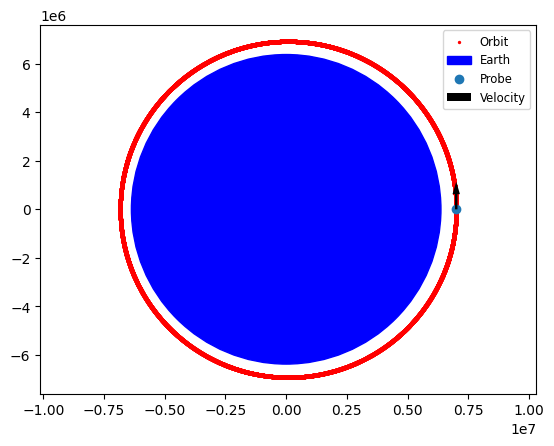

In [19]:
# Plotting the Output
plt.scatter(sol.y[0, :], sol.y[1, :], c='r', label='Orbit', s=2)
Earth = plt.Circle((0, 0), 6371e3, color='blue', label='Earth')
plt.gca().add_patch(Earth)
plt.scatter(r0[0], r0[1], label='Probe')
plt.quiver(r0[0], r0[1], v0[0], v0[1], headaxislength=5, width=0.005, label='Velocity')
plt.axis('equal')
# plt.title(f'Orbit over {tf/(60*60*24*365):.4f} years for v0 = {7.500} km/s')
# plt.grid()
plt.legend(loc='upper right', fontsize='small')
# plt.xlim(-8e6, 8e6)
# plt.ylim(-8e6, 8e11)
plt.show()

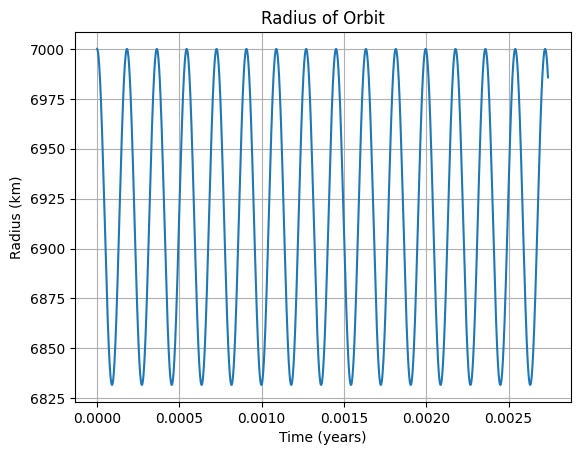

In [20]:
# Plotting other Orbit Features
radius_orbit = np.sqrt(sol.y[0, :]**2 + sol.y[1, :]**2 + sol.y[2, :]**2)
time_orbit = teval / (60 * 60)  # Time is in hours

plt.plot(time_orbit / (24*365), radius_orbit*1e-3)
plt.title('Radius of Orbit')
plt.ylabel('Radius (km)')
plt.xlabel('Time (years)')
plt.grid()
plt.show()

In [21]:
# Radius Info
print('Orbit Radius Range:', np.max(radius_orbit) - np.min(radius_orbit))
print('Mean Orbit Radius:', np.mean(radius_orbit))

if np.min(radius_orbit) <= 6371e3:
    print('Orbit Crashed ;)')

print('Minimum Orbit Radius:', np.min(radius_orbit))
# idx_min_radius_orbit = np.argmin(radius_orbit)
# velocity_atmin_radius_orbit = [sol.y[3, idx_min_radius_orbit], sol.y[4, idx_min_radius_orbit], sol.y[5, idx_min_radius_orbit]]
# print(velocity_atmin_radius_orbit)

Orbit Radius Range: 168298.44790204428
Mean Orbit Radius: 6916859.957697639
Minimum Orbit Radius: 6831701.575530605


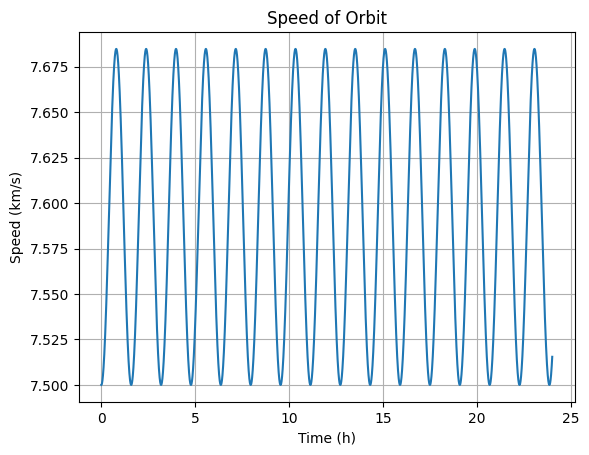

In [22]:
# Plotting other Orbit Features
speed_orbit = np.sqrt(sol.y[3, :]**2 + sol.y[4, :]**2 + sol.y[5, :]**2)
plt.plot(time_orbit, speed_orbit*1e-3)
plt.title('Speed of Orbit')
plt.ylabel('Speed (km/s)')
plt.xlabel('Time (h)')
plt.grid()
plt.show()

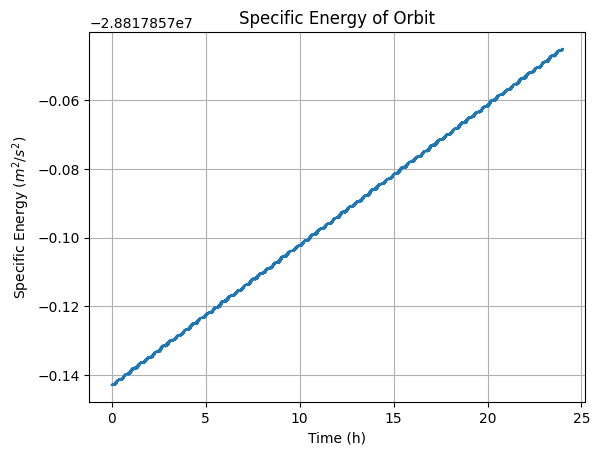

In [23]:
# Plotting other Orbit Features
sp_energy_orbit = speed_orbit**2/2 - mu/radius_orbit
plt.plot(time_orbit, sp_energy_orbit)
plt.title('Specific Energy of Orbit')
plt.ylabel(r'$\text{Specific Energy} \ (m^2/s^2)$')
plt.xlabel('Time (h)')
plt.grid()
plt.show()

In [24]:
# Specific Energy Info
print("Range of Specific Energy: ", np.max(sp_energy_orbit) - np.min(sp_energy_orbit))
print("Mean Specific Energy: ", np.mean(sp_energy_orbit))

Range of Specific Energy:  0.09782877564430237
Mean Specific Energy:  -28817857.094048604


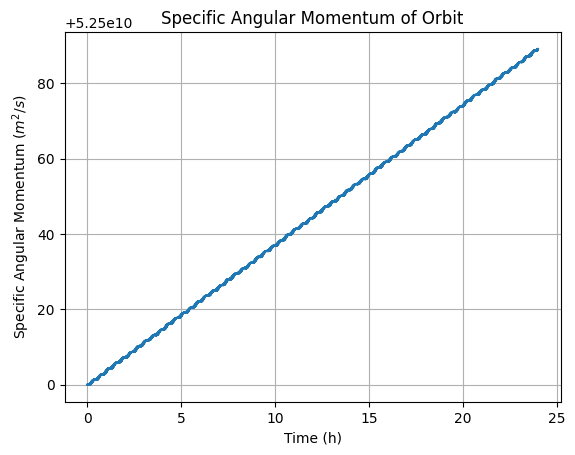

In [25]:
# Plotting other Orbit Features
position_vec_orbit = np.vstack((sol.y[0, :], sol.y[1, :], sol.y[2, :])).T
velocity_vec_orbit = np.vstack((sol.y[3, :], sol.y[4, :], sol.y[5, :])).T
sp_angmomentum_orbit = np.linalg.norm(np.cross(position_vec_orbit, velocity_vec_orbit), axis=1)
plt.plot(time_orbit, sp_angmomentum_orbit)
plt.title('Specific Angular Momentum of Orbit')
plt.ylabel(r'$\text{Specific Angular Momentum} \ (m^2/s)$')
plt.xlabel('Time (h)')
plt.grid()
plt.show()

In [26]:
# Specific Angular Momentum Info
print("Range of Specific Angular Momentum: ", np.max(sp_angmomentum_orbit) - np.min(sp_angmomentum_orbit))
print("Mean Specific Angular Momentum: ", np.mean(sp_angmomentum_orbit))

Range of Specific Angular Momentum:  89.14904022216797
Mean Specific Angular Momentum:  52500000044.437294


In [27]:
# Required Velocity for Circular Orbit
rad0 = np.linalg.norm(r0)
v_circ = np.sqrt(mu/rad0)
print("Velocity for Cicular Orbit:", v_circ)
v_escape = np.sqrt(2*mu/rad0)
print("Velocity for Escape:", v_escape)

Velocity for Cicular Orbit: 7546.049108166282
Velocity for Escape: 10671.724991102155
